In [9]:
# -*- coding: utf-8 -*-
from dataclasses import dataclass
import logging

from bfly_accelerator import Butterfly_Accelerator
from sim_bfly_cycle import baseline_0, baseline_1, bunet_simulation

# ----------------------- 配置载体（非全局） -----------------------
@dataclass
class Config:
    efficiency: float = 1.0
    debug: bool = False
    name: str = "0"
    # 体系结构相关
    parallesm_bu : int = 16
    parallesm_be : int = 4
    p_sub        : int = 1
    channel      : int = 8
    dim          : int = 32
    num_len_exp  : int = 1024
    num_len_0    : int = 1024
    num_len_1    : int = 128
    num_len_2    : int = 16
    offchip_mem: str = "on-chip"      #


# ----------------------- 带宽推导（非全局） -----------------------
def derive_bandwidth(offchip_mem: str):
    if offchip_mem == "on-chip":
        return 10e8, 10e8, 10e8   # indata, coef, outdata
    elif offchip_mem == "ddr3":
        return 64, 64, 128
    else:
        raise NotImplementedError("Not supported off-chip memory.")

# ----------------------- 小工具：打印 + 记日志 -----------------------
def logger_print(logger: logging.Logger, msg: str):
    print(msg)
    logger.info(msg)


In [10]:
cfg_0 = Config(
    name        = "0",
    channel     = 4,
    dim         = 32,
    num_len_exp = 1024,
    num_len_0   = 1024,
    num_len_1   = 128,
    num_len_2   = 16,
)


cfg_1 = Config(
    name        = "1",
    channel     = 8,
    dim         = 64,
    num_len_exp = 4096,
    num_len_0   = 512,
    num_len_1   = 64,
    num_len_2   = 8
)

cfg_2 = Config(
    name        = "2",
    channel     = 8,
    dim         = 64,
    num_len_exp = 4096,
    num_len_0   = 512,
    num_len_1   = 64,
    num_len_2   = -1,
)

cfg_3 = Config(
    name        = "3",
    channel     = 4,
    dim         = 32,
    num_len_exp = 8192,
    num_len_0   = 1024,
    num_len_1   = 128,
    num_len_2   = 16,
)

cfg_4 = Config(
    name        = "4",
    channel     = 4,
    dim         = 32,
    num_len_exp = 8192,
    num_len_0   = 1024,
    num_len_1   = 128,
    num_len_2   = 16,
)

cfg_5 = Config(
    name        = "5",
    channel     = 8,
    dim         = 32,
    num_len_exp = 4096,
    num_len_0   = 512,
    num_len_1   = 64,
    num_len_2   = 8,
)

cfg_6 = Config(
    name        = "6",
    channel     = 8,
    dim         = 32,
    num_len_exp = 4096,
    num_len_0   = 1024,
    num_len_1   = 128,
    num_len_2   = 16,
)

cfg_7 = Config(
    name        = "7",
    channel     = 16,
    dim         = 32,
    num_len_exp = 2048,
    num_len_0   = 1024,
    num_len_1   = 128,
    num_len_2   = 16,
)

cfg_8 = Config(
    name        = "8",
    channel     = 32,
    dim         = 32,
    num_len_exp = 1024,
    num_len_0   = 1024,
    num_len_1   = 128,
    num_len_2   = 16,
)

cfg_list = [ cfg_1, cfg_2, cfg_3, cfg_4, cfg_5, cfg_6, cfg_7, cfg_8 ]

logging.basicConfig(
    level    = logging.INFO,
    format   = " - %(message)s",
    filename = "log_fpga_sim.txt",
    filemode = "w",          # 覆盖写
    encoding = "utf-8",
    force    = True          # 3.8+：清除已有 handler，确保生效
)
logger = logging.getLogger(__name__)

# 3) 派生外存带宽（按配置）
in_bw, coef_bw, out_bw = derive_bandwidth("on-chip")


baseline_1_lat = []
baseline_2_lat = []
proposed_lat   = []

for i in range(len(cfg_list)):

    logger_print(logger, f"************************************ CONFIG {i} START ************************************")

    # baseline_0 / baseline_1 / bunet_simulation 都用 cfg_list[i]
    baseline_1_lat.append(baseline_0(cfg_list[i], logger, in_bw, coef_bw, out_bw))
    baseline_2_lat.append(baseline_1(cfg_list[i], logger, in_bw, coef_bw, out_bw))
    proposed_lat.append(bunet_simulation(cfg_list[i], logger, in_bw, coef_bw, out_bw, P_sub=1))

logger_print(logger, "************************************ DONE ALL ************************************")
logger_print(logger, f"**********************  run {i}    ***********************************")


************************************ CONFIG 0 START ************************************
input_data transfer cycles: 4096
weight_data transfer cycles: 1
fft compute cycles: 61440.0
*********************** num run is :  2731
input_data transfer cycles: 1
weight_data transfer cycles: 1
bfly compute cycles: 3.0
*********************** num run is :  43
input_data transfer cycles: 8
weight_data transfer cycles: 1
bfly compute cycles: 48.0
*********************** num run is :  43
input_data transfer cycles: 8
weight_data transfer cycles: 1
bfly compute cycles: 48.0
*********************** num run is :  6
input_data transfer cycles: 8
weight_data transfer cycles: 1
bfly compute cycles: 48.0
*********************** num run is :  6
input_data transfer cycles: 8
weight_data transfer cycles: 1
bfly compute cycles: 48.0
*********************** num run is :  1
input_data transfer cycles: 8
weight_data transfer cycles: 1
bfly compute cycles: 48.0
*********************** num run is :  1
input_data tr

In [11]:
import numpy as np

with np.printoptions(precision=4, suppress=True):
    
    baseline_1_lat = np.asarray(baseline_1_lat)
    baseline_2_lat = np.asarray(baseline_2_lat)
    proposed_lat  = np.asarray(proposed_lat)
    
    speedup_1 = np.asarray(baseline_1_lat) / np.asarray(proposed_lat)
    speedup_2 = np.asarray(baseline_2_lat) / np.asarray(proposed_lat)

    print ("flexbe 相对 base-1 : ", speedup_1)
    print (speedup_1.min(), speedup_1.max())

    print ("flexbe 相对 base-2 : ", speedup_2)
    print (speedup_2.min(), speedup_2.max())

    print ("base-1 cfg-6 吞吐峰值: ", 1000./baseline_1_lat[5])
    print ("flexbe cfg-6 吞吐峰值: ", 1000./proposed_lat[5])

    print (baseline_1_lat)
    print (baseline_2_lat)
    print (proposed_lat)


flexbe 相对 base-1 :  [2.3824 2.3865 3.091  3.091  2.506  2.1922 2.3971 2.595 ]
2.1922191499937864 3.0909657149156655
flexbe 相对 base-2 :  [14.7549 14.8277 26.2393 26.2393  9.9781  8.6647  3.9373  2.7391]
2.739130434782609 26.2393053831369
base-1 cfg-6 吞吐峰值:  2232.043212356591
flexbe cfg-6 吞吐峰值:  4893.127873741767
[0.5226 0.5203 0.7121 0.7121 0.4192 0.448  0.4276 0.4122]
[3.2365 3.2329 6.0449 6.0449 1.6692 1.7708 0.7023 0.4351]
[0.2194 0.218  0.2304 0.2304 0.1673 0.2044 0.1784 0.1589]


In [12]:
# train on 2018,  test on 2022,  non-quant
acc_18_18 = [ 84.5, 84.4, 84.5, 79.3, 84.1, 84.7, 84.4, 83.3 ]
acc_18_22 = [ 78.3, 77.4, 78.3, 75.1, 77.9, 78.3, 77.8, 77.3 ]
avg_18 = [(x + y) / 2. for x, y in zip(acc_18_18, acc_18_22)]
print (avg_18)
# train on 2022, test on 2018
acc_22_18 = [ 81.1, 80.5, 81.1, 75.8, 80.6, 81.2, 80.7, 79.8 ]
acc_22_22 = [ 83.5, 82.8, 83.7, 80.5, 83.3, 83.6, 83.2, 82.7 ]
avg_22 = [(x + y - .4) / 2. for x, y in zip(acc_22_18, acc_22_22)]
print (avg_22)

[81.4, 80.9, 81.4, 77.19999999999999, 81.0, 81.5, 81.1, 80.3]
[82.1, 81.45, 82.2, 77.95, 81.74999999999999, 82.2, 81.75, 81.05]


/tmp/ipykernel_3439898/645297194.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


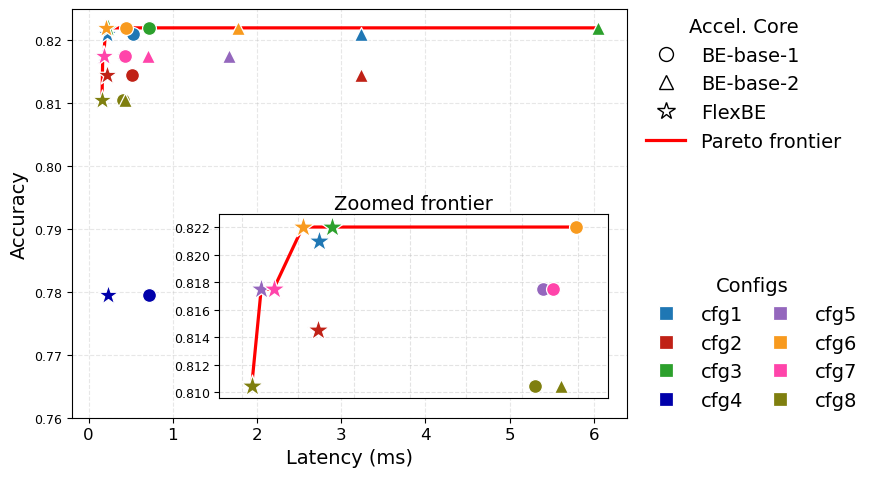

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D


acc_arr = np.array(avg_22, dtype=float) / 100.0
# ====== 数据定义结束 ======


plt.rcParams['font.size'] = 14  # 所有文本基准字号
# 可选：细分控制
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize']  = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 14


# ---- 颜色（8 种 cfg） ----
config_colors = [
    "#1f77b4", "#c02116ff", "#2ca02c", "#0000AA",
    "#9467bd", "#f89a1e",   "#ff44aa", "#7f7f0f" # (修改了最后一个颜色避免与灰色重复)
]
# ---- 平台形状 ----
marker_b0 = "o"   # baseline-0
marker_b1 = "^"   # baseline-1
marker_pp = "*"   # proposed
# ---- Pareto 线颜色 ----
pareto_color = "#FF0000"

POINT_SIZE = 100   # ⬅ 把点放大；你可以继续调大

def scatter_points(ax, lat_list, marker, ps=POINT_SIZE, z=10):
    # 此函数假设 lat_list 和全局的 acc_arr 是一一对应的
    for i in range(len(acc_arr)):
        ax.scatter(lat_list[i], acc_arr[i],
                   s=ps, marker=marker,
                   color=config_colors[i],
                   edgecolors="white", linewidths=0.9, zorder=z)

def compute_pareto(b0, b1, pp):
    # 注意：此函数假设 b0, b1, pp 都对应同一个 acc_arr
    # lat_all = np.array(b0 + b1 + pp, dtype=float)
    lat_all = np.concatenate([b0, b1, pp])
    acc_all = np.concatenate([acc_arr, acc_arr, acc_arr]) # 将 acc_arr 重复三次
    
    order = np.argsort(lat_all)
    lat_sorted = lat_all[order]
    acc_sorted = acc_all[order]
    
    frontier_idx, best_acc = [], -np.inf
    for idx, (l, a) in enumerate(zip(lat_sorted, acc_sorted)):
        # 帕累托前沿：在延迟更低（已排序）的情况下，寻找准确率更高（或相等）的点
        if a >= best_acc:
            frontier_idx.append(idx)
            best_acc = a
            
    return lat_sorted[frontier_idx], acc_sorted[frontier_idx], lat_all, acc_all

def legends_outside(ax):
    platform_handles = [
        Line2D([0], [0], marker=marker_b0, color="none",
               markerfacecolor="#ffffff", markeredgecolor="#000000",
               markersize=10, label="BE-base-1"),
        Line2D([0], [0], marker=marker_b1, color="none",
               markerfacecolor="#ffffff", markeredgecolor="#000000",
               markersize=10, label="BE-base-2"),
        Line2D([0], [0], marker=marker_pp, color="none",
               markerfacecolor="#ffffff", markeredgecolor="#000000",
               markersize=13, label="FlexBE"),
        Line2D([0], [0], color=pareto_color, lw=2.3, label="Pareto frontier"),
    ]
    cfg_handles = [
        Line2D([0], [0], marker="s", color="none",
               markerfacecolor=config_colors[i], markeredgecolor="white",
               markeredgewidth=0.9, markersize=10, label=f"cfg{i+1}")
        for i in range(8)
    ]
    leg1 = ax.legend(handles=platform_handles, loc="upper left",
                     bbox_to_anchor=(1.02, 1.00), frameon=False,
                     title="Accel. Core", borderaxespad=0.0)
    ax.add_artist(leg1)
    leg2 = ax.legend(handles=cfg_handles, loc="lower left",
                     bbox_to_anchor=(1.02, 0.00), frameon=False,
                     title="Configs", borderaxespad=0.0, ncol=2, columnspacing=0.9)

# ====== 图1：全局视图 + 右下角内嵌放大图 ======
lat_front, acc_front, lat_all, acc_all = compute_pareto(
    baseline_1_lat, baseline_2_lat, proposed_lat
)

fig, ax = plt.subplots(figsize=(9., 5.))

# 全局：点
scatter_points(ax, baseline_1_lat, marker_b0)
scatter_points(ax, baseline_2_lat, marker_b1)
scatter_points(ax, proposed_lat,   marker_pp, ps=230)

# 全局：Pareto 线
ax.plot(lat_front, acc_front, color=pareto_color, linewidth=2.3, zorder=5)

# 轴/网格
ax.set_xlabel("Latency (ms)")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.76, 0.825) # (根据你的数据，0.75 到 0.90 可能更合适)
xmin, xmax = lat_all.min(), lat_all.max()
pad = 0.06 * (xmax - xmin if xmax > xmin else 1.0)
ax.set_xlim(xmin - pad, xmax + pad)
ax.grid(True, which="both", linestyle="--", alpha=0.3)

# 图外图例
legends_outside(ax)

# ==== 在图1中加入“前沿放大” inset ====
# 位置：相对主轴，右下角；你可以微调 width/height/loc
in_ax = inset_axes(ax, width="70%", height="45%", loc="lower right",
                   borderpad=1.0)
# 只隐藏小图的“横坐标”（x 轴刻度与标签）
in_ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
in_ax.set_xlabel(None)              # 防止遗留 xlabel
# in_ax.spines['bottom'].set_visible(False) # 可选：把下边框也隐藏

# print(lat_front) # 打印前沿点
# 计算前沿范围并加 padding
# 过滤 frontier 上 latency > 1ms 的点
mask = lat_front <= 0.7
lat_front = lat_front[mask]
acc_front = acc_front[mask]

x_lo, x_hi = lat_front.min(), lat_front.max()
y_lo, y_hi = acc_front.min(), acc_front.max()
x_pad = 0.10 * (x_hi - x_lo if x_hi > x_lo else (lat_all.max()-lat_all.min())*0.10 + 1e-12)
y_pad = 0.08 * (y_hi - y_lo if y_hi > y_lo else 0.01)

# 放大图：点（同样放大大小/颜色/形状）
scatter_points(in_ax, baseline_1_lat, marker_b0, z=4)
scatter_points(in_ax, baseline_2_lat, marker_b1, z=4)
scatter_points(in_ax, proposed_lat,   marker_pp, ps=270, z=4)
# 放大图：Pareto 线
in_ax.plot(lat_front, acc_front, color=pareto_color, linewidth=2.3, zorder=3)

# 放大图轴范围
in_ax.set_xlim(x_lo - x_pad, x_hi + x_pad)
in_ax.set_ylim(max(0.70, y_lo - y_pad), min(0.90, y_hi + y_pad))

# 放大图外观（不加图例，刻度保留更易读）
in_ax.grid(True, which="both", linestyle="--", alpha=0.35)
in_ax.set_title("Zoomed frontier", pad=4)

plt.tight_layout()
fig.savefig("pf_lat_acc.svg", bbox_inches="tight")
plt.show()

# 吞吐对比 CPU GPU

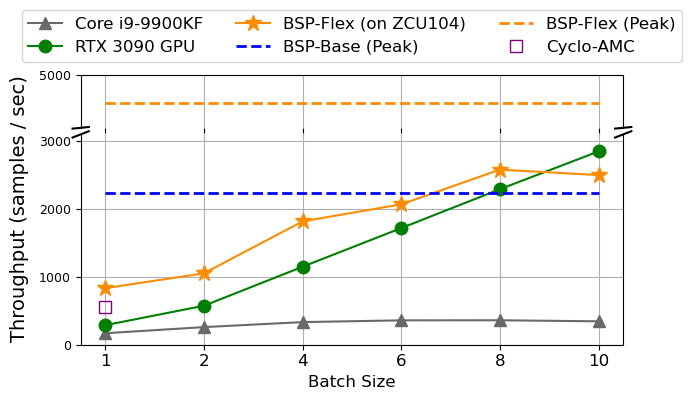

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# --- 1. 定义数据 ---
x_labels = ['1', '2', '4', '6', '8', '10']
x_coords = np.arange(len(x_labels))

batch_sizes = [1, 2, 4, 6, 8, 10]

cpu_i9_latency = [0.0059, 0.0077, 0.012, 0.0167, 0.0222, 0.029]
gpu_latency = [0.00347, 0.00348, 0.00348, 0.00349, 0.00349, 0.00351]
zcu_latency = [0.0012, 0.0019, 0.0022, 0.0029, 0.0031, 0.004]

cpu_y = [round(b / t, 2) for b, t in zip(batch_sizes, cpu_i9_latency)]
gpu_y = [round(b / t, 2) for b, t in zip(batch_sizes, gpu_latency)]
zcu_y = [round(b / t, 2) for b, t in zip(batch_sizes, zcu_latency)]

# theoretical upper limit of fpga accelerator
be_base_y = [2232.04, 2232.04, 2232.04, 2232.04, 2232.04, 2232.04]
flexbe_y = [4893.13, 4893.13, 4893.13, 4893.13, 4893.13, 4893.13]

# Accel. A: 1.8ms 延迟 = 1 / (1.8e-3) = 555.56 samples/s
accel_a_x = 0  # 对应 Batch Size '1'
accel_a_y = 555.56

# --- 2. 创建带有两个子图的画布 (用于 Y 轴截断) ---
# 使用 gridspec_kw 指定 1:4 的高度比例 (顶部:底部)
fig, (ax2, ax1) = plt.subplots(2, 1, sharex=True, figsize=(7, 3.5), 
                              gridspec_kw={'height_ratios': [1, 4]})
fig.subplots_adjust(hspace=0.05)  # 调整两个图之间的垂直间距

# --- 3. 在两个轴上都绘制所有数据 ---
# 1. CPU (灰色)
ax1.plot(x_coords, cpu_y, color='dimgrey', marker='^', markersize=9, label='Core i9-9900KF')
ax2.plot(x_coords, cpu_y, color='dimgrey', marker='^', markersize=9)

# 2. GPU (浅绿色)
ax1.plot(x_coords, gpu_y, color='green', marker='o', markersize=9, label='RTX 3090 GPU') 
ax2.plot(x_coords, gpu_y, color='green', marker='o', markersize=9)

# 3. ZCU (深绿色)
ax1.plot(x_coords, zcu_y, color='darkorange', marker='*', markersize=12, label='BSP-Flex (on ZCU104)')
ax2.plot(x_coords, zcu_y, color='darkorange', marker='*', markersize=12)

# 4. BE-Base-0 (浅蓝色)
ax1.plot(x_coords, be_base_y, color='blue', linestyle='--', linewidth=2, label='BSP-Base (Peak)')
ax2.plot(x_coords, be_base_y, color='blue', linestyle='--', linewidth=2)

# 5. FlexBE (浅橙色/红色)
ax1.plot(x_coords, flexbe_y, color='darkorange', linestyle='--', linewidth=2, label='BSP-Flex (Peak)')
ax2.plot(x_coords, flexbe_y, color='darkorange', linestyle='--', linewidth=2)

# 6. Accel. A (紫色点)
ax1.plot(accel_a_x, accel_a_y, color='purple', marker='s', markerfacecolor='none', markersize=8, linestyle='None', label='Cyclo-AMC')
ax2.plot(accel_a_x, accel_a_y, color='purple', marker='s', markerfacecolor='none', markersize=8, linestyle='None')

# --- 4. 设置 Y 轴的 "截断" 范围 ---
# ****************** 修改部分 ******************
# 将下半图的最大值放宽到 3100 以完全包容 GPU 的 2849
ax1.set_ylim(0, 3100)   
ax2.set_ylim(4800, 5000) 
# **********************************************

# --- 5. 绘制 "截断" 标记 (斜线) ---
ax1.spines['top'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax1.xaxis.tick_bottom()
ax2.tick_params(labeltop=False)  # 隐藏顶部图的 x 轴标签
ax2.xaxis.tick_bottom()

d = .015  # 斜线的尺寸，稍微加大一点防止看不清
kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False)
ax2.plot((-d, +d), (-d, +d), **kwargs)        # top-left
ax2.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right

kwargs.update(transform=ax1.transAxes)  # 切换到下半图
ax1.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right

# --- 6. 设置标签和刻度 ---
plt.xlabel('Batch Size', fontsize=12)
fig.text(0.024, 0.5, 'Throughput (samples / sec)', va='center', rotation='vertical', fontsize=14)
plt.xticks(x_coords, x_labels)

# ****************** 修改部分 ******************
# 重新适配 Y 轴刻度，避免堆叠
ax1.set_yticks([0, 1000, 2000, 3000])
ax2.set_yticks([5000])
# **********************************************

ax1.grid(True)
ax2.grid(True)

# --- 7. 为整个 Figure 创建一个统一的图例 ---
handles, labels = ax1.get_legend_handles_labels()
ax2.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.1),
           ncol=3, fontsize=12)

# --- 8. 保存并显示 ---
output_filename = "tp_compare.svg"
plt.savefig(output_filename, bbox_inches='tight')
plt.show()

# 功耗对比

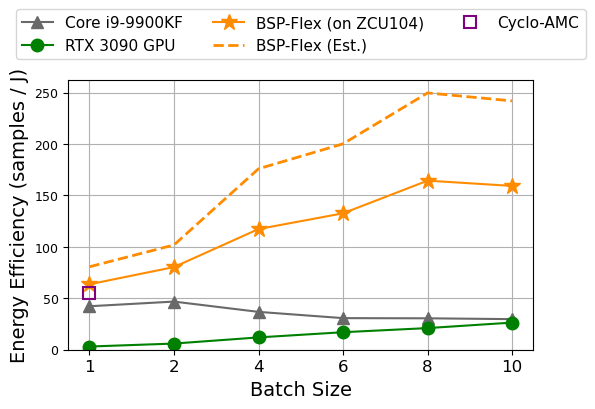

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# --- 1. 定义基础数据 ---
x_labels = ['1', '2', '4', '6', '8', '10']
x_coords = np.arange(len(x_labels))

# 吞吐量 (Throughput, samples/s)
cpu_y_tp = np.array(cpu_y)
gpu_y_tp = np.array(gpu_y)
zcu_y_tp = np.array(zcu_y)

# FlexBE Estimated 吞吐量
flex_ext_tp = np.array([4893.13, 4893.13, 4893.13, 4893.13, 4893.13, 4893.13])

# 功耗 (Power, W)
cpu_y_power = np.array([4.01, 5.55, 9.06, 11.7, 11.8, 11.6])
gpu_y_power = np.array([93, 96, 96, 101, 109, 108])
zcu_y_power = np.array([13.1, 13.1, 15.5, 15.6, 15.7, 15.7])

# FlexBE Estimated 功耗
est_power = np.array([10.336, 10.336, 10.336, 10.336, 10.336, 10.336])


# --- 2. 计算能量效率 (Energy Efficiency, samples/s/W) ---
cpu_y_ee = cpu_y_tp / cpu_y_power
gpu_y_ee = gpu_y_tp / gpu_y_power
zcu_y_ee = zcu_y_tp / zcu_y_power

# *** 新增计算: FlexBE Estimated EE ***
flex_ext_ee = zcu_y_tp / est_power

# Cyclo-AMC (单点数据)
cyclo_amc_x = 0  # 对应 Batch Size '1'
cyclo_amc_y = 555.56 / 10.0

# --- 3. 创建画布 ---
fig, ax = plt.subplots(figsize=(6, 3.5))

# --- 4. 绘制所有数据 ---

# 1. CPU (灰色)
ax.plot(x_coords, cpu_y_ee, color='dimgrey', marker='^', markersize=9, label='Core i9-9900KF')

# 2. GPU (浅绿色)
ax.plot(x_coords, gpu_y_ee, color='green', marker='o', markersize=9, label='RTX 3090 GPU')

# 3. ZCU (深绿色) - Ours (Measured)
ax.plot(x_coords, zcu_y_ee, color='darkorange', marker='*', markersize=12, label='BSP-Flex (on ZCU104)')

# 4. FlexBE Estimated (深绿色虚线) - *** 新增绘图 ***
ax.plot(x_coords, flex_ext_ee, color='darkorange', linestyle='--', linewidth=2, label='BSP-Flex (Est.)')

# 5. Cyclo-AMC (紫色点)
ax.plot(cyclo_amc_x, cyclo_amc_y, color='purple', marker='s', markersize=9, 
        markerfacecolor='none', markeredgewidth=1.5, linestyle='None', label='Cyclo-AMC')


# --- 6. 设置标签和刻度 ---
ax.set_xlabel('Batch Size', fontsize=14)
ax.set_ylabel('Energy Efficiency (samples / J)', fontsize=14)
ax.set_xticks(x_coords)
ax.set_xticklabels(x_labels)

# 设置 Y 轴从 0 开始
ax.set_ylim(bottom=0) 
ax.grid(True)


# --- 7. 创建图例 ---
handles, labels = ax.get_legend_handles_labels()
# 调整图例列数 (ncol) 为 3 或者保持 2，取决于显示效果。这里设为 2 会增加一行。
ax.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.05),
           ncol=3, fontsize=11) # 稍微调小字体以适应增加的条目

# --- 8. 保存并显示 ---
output_filename = "ee_compare.svg"
plt.savefig(output_filename, bbox_inches='tight')
plt.show()

In [16]:
print (zcu_y_ee)

[ 63.6129771   80.35343511 117.30193548 132.62628205 164.37261146
 159.23566879]
